## Merges all the availble information into a **Final Dataset** to be used for modeling ##

In [1]:
import pandas as pd
import datetime
import math
import numpy as np
import missingno
import json
from statistics import mean
import re
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import KNNImputer
import sys
import pickle

sys.path.insert(0, "../../../Modules")
sys.path.insert(0, "../../../Mamoth")

from utils import *
from Neural_Network_Module import give_predictions, Dataset


enc = 'utf-8'
dec = 'greek8'

pd.options.display.max_columns = None
pd.options.display.max_rows = 10

In [2]:
import warnings
warnings.filterwarnings('ignore')

In [3]:
NUTS0 = 'GR'
NUTS2 = 'Attica'
NUTS2_EL = 'αττικης'

In [4]:
YEAR = 2023
MONTH = 'August'
PERIOD = '2nd'

In [5]:
timeline_file = pd.read_csv(f'../../data/{NUTS2}/{NUTS0}_{NUTS2}_Timeline_{YEAR}-{MONTH}-{PERIOD}_filled.csv', encoding=enc)
#wnv_file = pd.read_csv(f'../../data/{NUTS2}/{NUTS0}_{NUTS2}_WNV_Timeline_2022.csv', encoding=enc)

In [6]:
timeline_file.head()

,lau1,region,x,y,dt_placement,year,month,indices_image_date,indices_lat,indices_lon,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_image_date,lst_lat,lst_lon,lst_day,lst_night,monthly_lst_lat,monthly_lst_lon,lst_jan_day_mean,lst_jan_night_mean,lst_feb_day_mean,lst_feb_night_mean,lst_mar_day_mean,lst_mar_night_mean,lst_apr_day_mean,lst_apr_night_mean,indices_image_date.1,indices_lat.1,indices_lon.1,acc_rainfall_jan,dt_placement_minus_7,dt_placement_minus_14,dt_placement_minus_7_avail,dt_placement_minus_14_avail,acc_rainfall_1week,acc_rainfall_2week
0,αγιας βαρβαρας,αττικης,23.65697,37.99220,2023-08-16,2023,8,2023-08-16,37.991999,23.654887,0.010814,0.055814,0.001571,-0.055814,0.048130,0.023736,-0.047578,-0.023736,0.042733,0.019531,0.049336,0.019531,2023-08-08,37.991999,23.654887,15556.0,15000.0,37.991999,23.654887,14383.000000,14058.500000,14342.555556,13972.380952,14651.923077,14207.846154,14829.846154,14265.500000,2023-08-16,37.950174,23.650108,348.910701,2023-08-09,2023-08-02,2023-08-09,2023-08-02,0.0,0.000000
1,αγιας παρασκευης,αττικης,23.82642,38.00806,2023-08-16,2023,8,2023-08-16,38.009965,23.825567,0.191321,0.024308,-0.222122,-0.024308,0.194652,0.028120,-0.220625,-0.028120,0.022706,0.014833,0.016365,0.014833,2023-08-08,38.009965,23.825567,15439.0,14927.0,38.009965,23.825567,14333.928571,14047.200000,14411.600000,13959.363636,14596.000000,14136.000000,14752.555556,14223.200000,2023-08-16,38.050174,23.850109,425.951674,2023-08-09,2023-08-02,2023-08-09,2023-08-02,0.0,0.000000
2,αγιου δημητριου,αττικης,23.73031,37.93357,2023-08-16,2023,8,2023-08-16,37.933609,23.731244,0.117532,-0.028843,-0.179234,0.028843,0.041143,-0.007720,-0.067075,0.007720,0.000000,0.000000,0.000000,0.000000,2023-08-08,37.933609,23.731244,15489.0,14991.0,37.933609,23.731244,14390.461538,14124.550000,14357.363636,13996.130435,14688.400000,14187.062500,14885.647059,14302.500000,2023-08-16,37.950174,23.750109,365.646401,2023-08-09,2023-08-02,2023-08-09,2023-08-02,0.0,0.000000
3,αγιων αναργυρων καματερου,αττικης,23.71341,38.04721,2023-08-16,2023,8,2023-08-16,38.045898,23.713278,0.133692,-0.070526,-0.189098,0.070526,0.167988,-0.068353,-0.211268,0.068353,0.022130,0.026346,0.020000,0.026346,2023-08-08,38.045898,23.713278,15576.0,14994.0,38.045898,23.713278,14369.750000,14037.578947,14313.300000,13963.473684,14693.000000,14156.333333,14841.250000,14223.666667,2023-08-16,38.050174,23.750109,437.278102,2023-08-09,2023-08-02,2023-08-09,2023-08-02,0.0,0.000000
4,αγκιστριου,αττικης,23.34009,37.69503,2023-08-16,2023,8,2023-08-16,37.695555,23.340477,0.292929,-0.052133,-0.238870,0.052133,0.305424,-0.037109,-0.253252,0.037109,0.025965,0.053238,0.012187,0.053238,2023-08-08,37.695555,23.340477,15225.0,14979.0,37.695555,23.340477,14368.608696,14189.722222,14305.315789,14124.388889,14433.318182,14238.400000,14545.680000,14261.666667,2023-08-16,37.650172,23.350107,485.616961,2023-08-09,2023-08-02,2023-08-09,2023-08-02,0.0,0.008986


In [7]:
#wnv_file.head()

In [8]:
timeline_file.rename(columns={"region": "nuts2"}, inplace=True)

In [9]:
timeline_file.drop(columns=['indices_image_date', 'indices_lat', 'indices_lon' , 'lst_image_date', 'lst_lat','lst_lon' ,'monthly_lst_lat', 'monthly_lst_lon', 
                         'indices_image_date.1', 'indices_lat.1', 'indices_lon.1', 'dt_placement_minus_7', 'dt_placement_minus_14', 'dt_placement_minus_7_avail',
                         'dt_placement_minus_14_avail'], inplace = True)

In [10]:
timeline_file.head(5)

,lau1,nuts2,x,y,dt_placement,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,lst_jan_day_mean,lst_jan_night_mean,lst_feb_day_mean,lst_feb_night_mean,lst_mar_day_mean,lst_mar_night_mean,lst_apr_day_mean,lst_apr_night_mean,acc_rainfall_jan,acc_rainfall_1week,acc_rainfall_2week
0,αγιας βαρβαρας,αττικης,23.65697,37.99220,2023-08-16,2023,8,0.010814,0.055814,0.001571,-0.055814,0.048130,0.023736,-0.047578,-0.023736,0.042733,0.019531,0.049336,0.019531,15556.0,15000.0,14383.000000,14058.500000,14342.555556,13972.380952,14651.923077,14207.846154,14829.846154,14265.500000,348.910701,0.0,0.000000
1,αγιας παρασκευης,αττικης,23.82642,38.00806,2023-08-16,2023,8,0.191321,0.024308,-0.222122,-0.024308,0.194652,0.028120,-0.220625,-0.028120,0.022706,0.014833,0.016365,0.014833,15439.0,14927.0,14333.928571,14047.200000,14411.600000,13959.363636,14596.000000,14136.000000,14752.555556,14223.200000,425.951674,0.0,0.000000
2,αγιου δημητριου,αττικης,23.73031,37.93357,2023-08-16,2023,8,0.117532,-0.028843,-0.179234,0.028843,0.041143,-0.007720,-0.067075,0.007720,0.000000,0.000000,0.000000,0.000000,15489.0,14991.0,14390.461538,14124.550000,14357.363636,13996.130435,14688.400000,14187.062500,14885.647059,14302.500000,365.646401,0.0,0.000000
3,αγιων αναργυρων καματερου,αττικης,23.71341,38.04721,2023-08-16,2023,8,0.133692,-0.070526,-0.189098,0.070526,0.167988,-0.068353,-0.211268,0.068353,0.022130,0.026346,0.020000,0.026346,15576.0,14994.0,14369.750000,14037.578947,14313.300000,13963.473684,14693.000000,14156.333333,14841.250000,14223.666667,437.278102,0.0,0.000000
4,αγκιστριου,αττικης,23.34009,37.69503,2023-08-16,2023,8,0.292929,-0.052133,-0.238870,0.052133,0.305424,-0.037109,-0.253252,0.037109,0.025965,0.053238,0.012187,0.053238,15225.0,14979.0,14368.608696,14189.722222,14305.315789,14124.388889,14433.318182,14238.400000,14545.680000,14261.666667,485.616961,0.0,0.008986


In [11]:
#wnv_file.head(5)

### Merge Timeline and WNV Case Files ###

In [12]:
# ## Find if there are lau1 units in the epidemiological file and are not contained in the spatiotemporal file.

# names_from_wnv_file = wnv_file["lau1"].drop_duplicates().sort_values().tolist()
# names_from_shapefile = timeline_file["lau1"].drop_duplicates().sort_values().tolist()
# diff = []

# for element in names_from_wnv_file:
#     if element not in names_from_shapefile:
#         diff.append(element)
        

# print(f"{diff}\n\nLength: {len(diff)}")


In [13]:
#wnv_file['lau1'] = wnv_file['lau1'].apply(lambda x : x.replace('ηρωικης πολεως ναουσας','ναουσας'))

In [14]:
# ## Check again

# names_from_wnv_file = wnv_file["lau1"].drop_duplicates().sort_values().tolist()
# names_from_shapefile = timeline_file["lau1"].drop_duplicates().sort_values().tolist()
# diff = []

# for element in names_from_wnv_file:
#     if element not in names_from_shapefile:
#         diff.append(element)
        

# print(f"{diff}\n\nLength: {len(diff)}")

In [15]:
# merged = timeline_file.merge(wnv_file, how='left', on=['dt_placement', 'lau1', 'nuts2'] )
merged = timeline_file

In [16]:
# merged

In [17]:
# merged = fillna(merged,{'case': 0})
merged['case'] = 0

In [18]:
merged['case'].value_counts()

0    272
Name: case, dtype: int64

In [19]:
grouped = merged.groupby(['dt_placement', 'lau1', 'nuts2'], as_index = False)
dataset = grouped.mean()
dataset

,dt_placement,lau1,nuts2,x,y,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,lst_jan_day_mean,lst_jan_night_mean,lst_feb_day_mean,lst_feb_night_mean,lst_mar_day_mean,lst_mar_night_mean,lst_apr_day_mean,lst_apr_night_mean,acc_rainfall_jan,acc_rainfall_1week,acc_rainfall_2week,case
0,2023-08-16,αγιας βαρβαρας,αττικης,23.656970,37.992200,2023.0,8.0,0.010814,0.055814,0.001571,-0.055814,0.048130,0.023736,-0.047578,-0.023736,0.042733,0.019531,0.049336,0.019531,15556.000000,15000.000000,14383.000000,14058.500000,14342.555556,13972.380952,14651.923077,14207.846154,14829.846154,14265.500000,348.910701,0.0,0.000000,0.0
1,2023-08-16,αγιας παρασκευης,αττικης,23.826420,38.008060,2023.0,8.0,0.191321,0.024308,-0.222122,-0.024308,0.194652,0.028120,-0.220625,-0.028120,0.022706,0.014833,0.016365,0.014833,15439.000000,14927.000000,14333.928571,14047.200000,14411.600000,13959.363636,14596.000000,14136.000000,14752.555556,14223.200000,425.951674,0.0,0.000000,0.0
2,2023-08-16,αγιου δημητριου,αττικης,23.730310,37.933570,2023.0,8.0,0.117532,-0.028843,-0.179234,0.028843,0.041143,-0.007720,-0.067075,0.007720,0.000000,0.000000,0.000000,0.000000,15489.000000,14991.000000,14390.461538,14124.550000,14357.363636,13996.130435,14688.400000,14187.062500,14885.647059,14302.500000,365.646401,0.0,0.000000,0.0
3,2023-08-16,αγιων αναργυρων καματερου,αττικης,23.713410,38.047210,2023.0,8.0,0.133692,-0.070526,-0.189098,0.070526,0.167988,-0.068353,-0.211268,0.068353,0.022130,0.026346,0.020000,0.026346,15576.000000,14994.000000,14369.750000,14037.578947,14313.300000,13963.473684,14693.000000,14156.333333,14841.250000,14223.666667,437.278102,0.0,0.000000,0.0
4,2023-08-16,αγκιστριου,αττικης,23.340090,37.695030,2023.0,8.0,0.292929,-0.052133,-0.238870,0.052133,0.305424,-0.037109,-0.253252,0.037109,0.025965,0.053238,0.012187,0.053238,15225.000000,14979.000000,14368.608696,14189.722222,14305.315789,14124.388889,14433.318182,14238.400000,14545.680000,14261.666667,485.616961,0.0,0.008986,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
61,2023-08-16,φιλοθεης ψυχικου,αττικης,23.776280,38.014770,2023.0,8.0,0.270066,0.052220,-0.277910,-0.052220,0.241266,0.033742,-0.260575,-0.033742,0.028055,0.024144,0.020873,0.024144,15471.000000,14903.000000,14336.631579,14058.052632,14351.083333,13962.608696,14601.846154,14136.722222,14814.133333,14253.928571,437.278102,0.0,0.000000,0.0
62,2023-08-16,φυλης,αττικης,23.672940,38.105580,2023.0,8.0,0.309681,0.019178,-0.284842,-0.019178,0.244765,0.020092,-0.209366,-0.020092,0.038511,0.033112,0.043795,0.033112,15418.500000,14820.000000,14321.314273,13955.547386,14289.078047,13877.732260,14537.344780,14033.446337,14739.469093,14115.791035,410.047369,0.0,0.000000,0.0
63,2023-08-16,χαλανδριου,αττικης,23.809410,38.022260,2023.0,8.0,0.216582,0.039957,-0.243138,-0.039957,0.223762,0.039369,-0.247848,-0.039369,0.047232,0.033458,0.032985,0.033458,15456.000000,14931.000000,14348.000000,14057.578947,14377.500000,13986.142857,14647.666667,14128.588235,14793.333333,14171.142857,425.951674,0.0,0.000000,0.0
64,2023-08-16,χαϊδαριου,αττικης,23.630840,38.009420,2023.0,8.0,0.276525,-0.059599,-0.261055,0.059599,0.280146,-0.032418,-0.259919,0.032418,0.025868,0.039354,0.012063,0.039354,15508.000000,14878.000000,14355.380952,14021.611111,14362.533333,13924.600000,14569.875000,14147.933333,14794.058824,14248.400000,439.846210,0.0,0.000000,0.0


In [20]:
dataset['x'] = dataset['x'].apply(lambda x : round(x,5))
dataset['y'] = dataset['y'].apply(lambda x : round(x,5))
dataset = dataset.astype({'case': 'int'})
dataset['dt_placement'] = pd.to_datetime(dataset['dt_placement'])
dataset['day'] = dataset['dt_placement'].apply(lambda x : x.day)
dataset['month'] = dataset['dt_placement'].apply(lambda x : x.month)
dataset['year'] = dataset['dt_placement'].apply(lambda x : x.year)
dataset['week'] = dataset.apply(lambda row: datetime.date(int(row['year']), int(row['month']), int(row['day'])).isocalendar().week, axis=1)
lau1_map = lau1_mapping(dataset, 0, 0)

In [21]:
dataset = encode_cyclical(dataset, 'day', 31)
dataset = encode_cyclical(dataset, 'month', 12)
dataset = encode_cyclical(dataset, 'week', 53)

### Add mosqutio predictions using trained model ###

In [22]:
model = pickle.load(open(f'../../data/{NUTS2}/{NUTS0}_{NUTS2}_Culex_Mamoth_NN.pt', 'rb'))
imputer = pickle.load(open(f'../../data/{NUTS2}/{NUTS0}_{NUTS2}_Culex_KNN_Imputer.pkl', 'rb'))
scaler = pickle.load(open(f'../../data/{NUTS2}/{NUTS0}_{NUTS2}_Culex_Scaler.pkl', 'rb'))

In [23]:
mamoth_columns = ['x', 'y', 'dt_placement', 'day', 'month', 'week', 'year',
                'day_sin', 'day_cos', 'month_sin', 'month_cos', 'week_sin', 'week_cos',
                'ndvi', 'ndwi', 'ndmi', 'ndbi', 'ndvi_mean', 'ndvi_std', 'ndwi_mean',
                'ndwi_std', 'ndmi_mean', 'ndmi_std', 'ndbi_mean', 'ndbi_std', 'lst_day',
                'lst_night', 'lst_jan_mean', 'lst_feb_mean', 'lst_mar_mean',
                'lst_apr_mean', 'acc_rainfall_1week', 'acc_rainfall_2week',
                'acc_rainfall_jan', 'mosq_now']

features_for_impute = ['x', 'y', 'day', 'month', 'week', 'year', 'day_sin', 'day_cos', 'month_sin', 'month_cos', 'week_sin', 'week_cos',
                        'ndvi', 'ndwi', 'ndmi', 'ndbi', 'ndvi_mean', 'ndvi_std', 'ndwi_mean', 'ndwi_std', 'ndmi_mean', 'ndmi_std', 'ndbi_mean', 'ndbi_std', 
                        'lst_day', 'lst_night', 'lst_jan_mean', 'lst_feb_mean', 'lst_mar_mean', 'lst_apr_mean', 'acc_rainfall_1week', 'acc_rainfall_2week', 'acc_rainfall_jan']

In [24]:
dataset_mamoth = dataset_mamoth_preparation(dataset, mamoth_columns)

In [25]:
mosqutio_predictions = dataset_mamoth[['x', 'y', 'dt_placement']].copy()

In [26]:
dataset_mamoth.drop(columns=['dt_placement'], inplace=True)

In [27]:
dataset_mamoth_sub = dataset_mamoth[features_for_impute]

In [28]:
mamoth_imputed = pd.DataFrame(imputer.transform(dataset_mamoth_sub), columns = dataset_mamoth_sub.columns)

In [29]:
dataset_mamoth[features_for_impute] = mamoth_imputed[features_for_impute]

<AxesSubplot:>

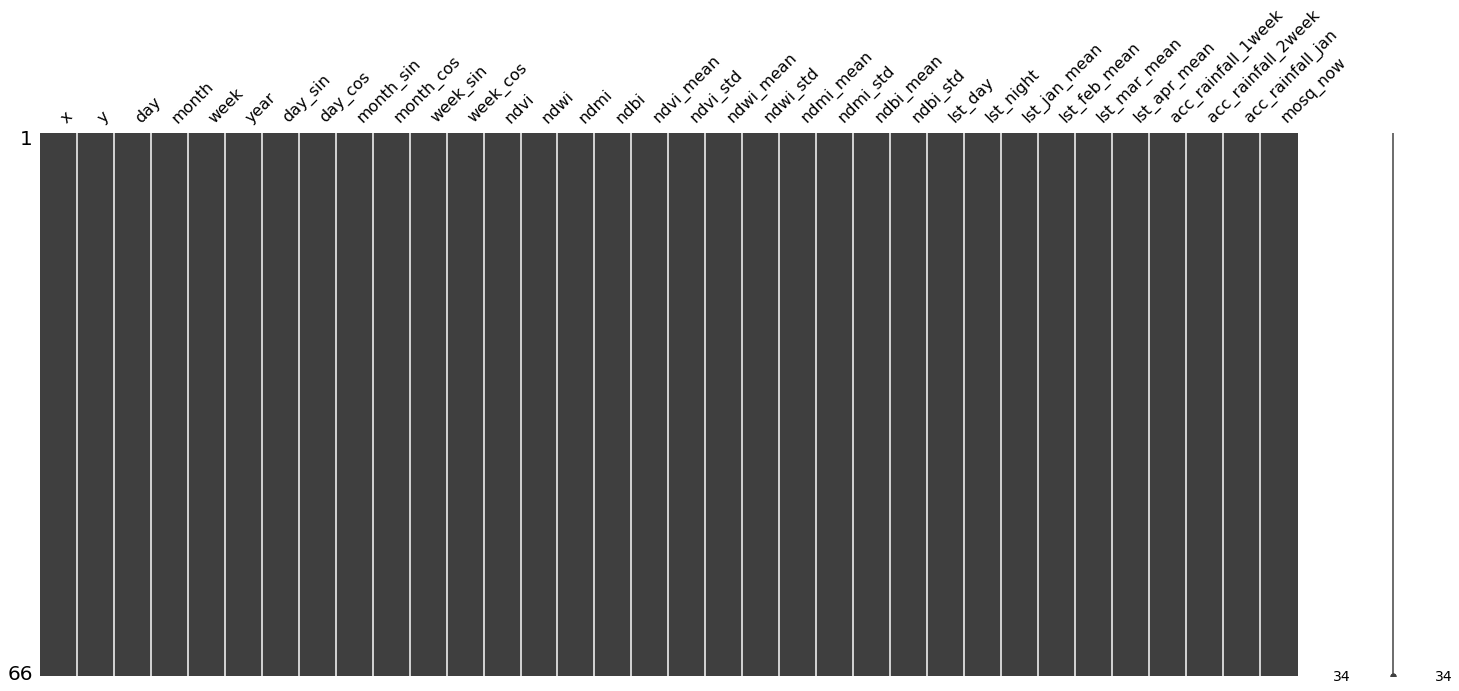

In [30]:
missingno.matrix(dataset_mamoth)

In [31]:
dataset_mamoth_X, dataset_mamoth_y = dataset_mamoth.iloc[:,:-1], dataset_mamoth.iloc[:,-1]

dataset_mamoth_X = scaler.transform(dataset_mamoth_X)

In [32]:
model_type = 'mosquito_regression'
transform_target = True

dataset_mamoth = Dataset(dataset_mamoth_X, dataset_mamoth_y, model_type=model_type, transform = transform_target)

In [33]:
predictions = give_predictions(model, dataset_mamoth)

In [34]:
mosqutio_predictions['mosq_pred'] = predictions
mosqutio_predictions

,x,y,dt_placement,mosq_pred
0,23.65697,37.99220,2023-08-16,180
1,23.82642,38.00806,2023-08-16,64
2,23.73031,37.93357,2023-08-16,172
3,23.71341,38.04721,2023-08-16,78
4,23.34009,37.69503,2023-08-16,57
...,...,...,...,...
61,23.77628,38.01477,2023-08-16,45
62,23.67294,38.10558,2023-08-16,46
63,23.80941,38.02226,2023-08-16,47
64,23.63084,38.00942,2023-08-16,43


In [35]:
#This cell writes the mosquito predictions to a seperate .csv file

# mosqutio_predictions.to_csv(f'../../data/{NUTS2}/{NUTS0}_{NUTS2}_Culex_Predictions_2010-2022.csv', index = False)

In [36]:
mosqutio_predictions['dt_placement'] = pd.to_datetime(mosqutio_predictions['dt_placement'])
dataset['dt_placement'] = pd.to_datetime(dataset['dt_placement'])

dataset['x.approx'] = dataset['x'].apply(lambda x : round(x,5))
dataset['y.approx'] = dataset['y'].apply(lambda x : round(x,5))

mosqutio_predictions['x.approx'] = mosqutio_predictions['x'].apply(lambda x : round(x,5))
mosqutio_predictions['y.approx'] = mosqutio_predictions['y'].apply(lambda x : round(x,5))

In [37]:
dataset = pd.merge(dataset, mosqutio_predictions,  how='left', on=['x.approx', 'y.approx', 'dt_placement'])

In [38]:
dataset['distance'] = dataset.apply(lambda row: compute_distance(row, x1='x_x', y1 = 'y_x', x2 = 'x_y', y2 = 'y_y'), axis=1)

In [39]:
dataset.distance.max()

0.0

In [40]:
dataset.drop(columns=['x.approx', 'y.approx', 'x_y', 'y_y', 'distance'], axis=1, inplace=True)
dataset.rename(columns={"x_x": "x", "y_x": "y"}, inplace=True)

In [41]:
dataset.reset_index(inplace=True, drop=True)

<AxesSubplot:>

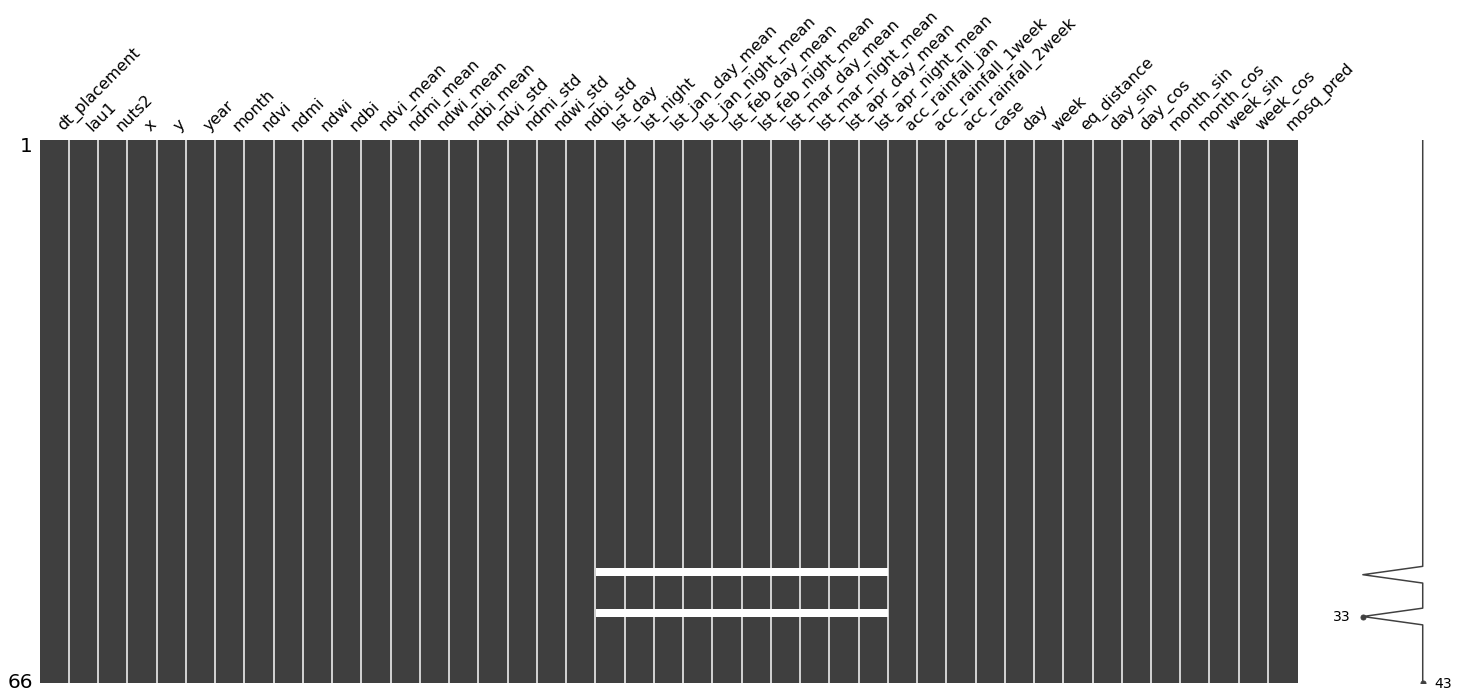

In [42]:
missingno.matrix(dataset)

### Add Demographic features ###

In [43]:
df_demographics = pd.read_csv(f'../../data/{NUTS0}_WEB_Demographics_Processed.csv', encoding = enc)

In [44]:
df_demographics

,lau1,nuts2,nuts3,area,population_density,population
0,αβδηρων,ανατολικης μακεδονιας και θρακης,ξανθης,352.0,54.0,17860.0
1,αγαθονησιου,νοτιου αιγαιου,καλυμνου,14.5,12.8,203.0
2,αγιας,θεσσαλιας,λαρισας,661.8,17.3,10705.0
3,αγιας βαρβαρας,αττικης,δυτικου τομεα αθηνων,2.4,10925.9,26759.0
4,αγιας παρασκευης,αττικης,βορειου τομεα αθηνων,7.9,7557.5,62157.0
...,...,...,...,...,...,...
327,χανιων,κρητης,χανιων,351.3,309.3,110646.0
328,χερσονησου,κρητης,ηρακλειου,272.2,98.2,27229.0
329,χιου,βορειου αιγαιου,χιου,842.3,61.0,50483.0
330,ωραιοκαστρου,κεντρικης μακεδονιας,θεσσαλονικης,217.9,175.8,40114.0


In [45]:
df_demographics_nuts2 = df_demographics.query(f"nuts2 == '{NUTS2_EL}'").copy()

In [46]:
df_demographics_nuts2.drop(columns=['nuts2', 'nuts3'], inplace=True)
df_demographics_nuts2.reset_index(inplace=True, drop=True)

In [47]:
df_demographics_nuts2

,lau1,area,population_density,population
0,αγιας βαρβαρας,2.4,10925.9,26759.0
1,αγιας παρασκευης,7.9,7557.5,62157.0
2,αγιου δημητριου,5.0,14402.8,71747.0
3,αγιων αναργυρων καματερου,9.2,6833.8,61427.0
4,αγκιστριου,13.4,85.2,1107.0
...,...,...,...,...
61,φιλοθεης ψυχικου,6.1,4421.0,27400.0
62,φυλης,109.1,421.2,48255.0
63,χαϊδαριου,22.7,2069.6,46983.0
64,χαλανδριου,10.8,6869.6,77118.0


In [48]:
names_from_merged = dataset["lau1"].drop_duplicates().sort_values().tolist()
names_from_demographics = df_demographics_nuts2["lau1"].drop_duplicates().sort_values().tolist()
diff = []

for element in names_from_merged:
    if element not in names_from_demographics:
        diff.append(element)
        

print(f"{diff}\n\nLength: {len(diff)}")

['νικαιας αγιου ι. ρεντη', 'πειραιως', 'τροιζηνιας', 'φιλαδελφειας χαλκηδονος']

Length: 4


In [49]:
df_demographics_nuts2['lau1'] = df_demographics_nuts2['lau1'].apply(lambda x : x.replace('νικαιας αγιου ιωαννη ρεντη', 'νικαιας αγιου ι. ρεντη'))
df_demographics_nuts2['lau1'] = df_demographics_nuts2['lau1'].apply(lambda x : x.replace('πειραια', 'πειραιως',))
df_demographics_nuts2['lau1'] = df_demographics_nuts2['lau1'].apply(lambda x : x.replace('τροιζηνιας μεθανων', 'τροιζηνιας'))
df_demographics_nuts2['lau1'] = df_demographics_nuts2['lau1'].apply(lambda x : x.replace('νεας φιλαδελφειας νεας χαλκηδονας','φιλαδελφειας χαλκηδονος'))


In [50]:
names_from_merged = dataset["lau1"].drop_duplicates().sort_values().tolist()
names_from_demographics = df_demographics_nuts2["lau1"].drop_duplicates().sort_values().tolist()
diff = []

for element in names_from_merged:
    if element not in names_from_demographics:
        diff.append(element)
        

print(f"{diff}\n\nLength: {len(diff)}")

[]

Length: 0


In [51]:
dataset = pd.merge(dataset, df_demographics_nuts2,  how='left', on=['lau1'])

<AxesSubplot:>

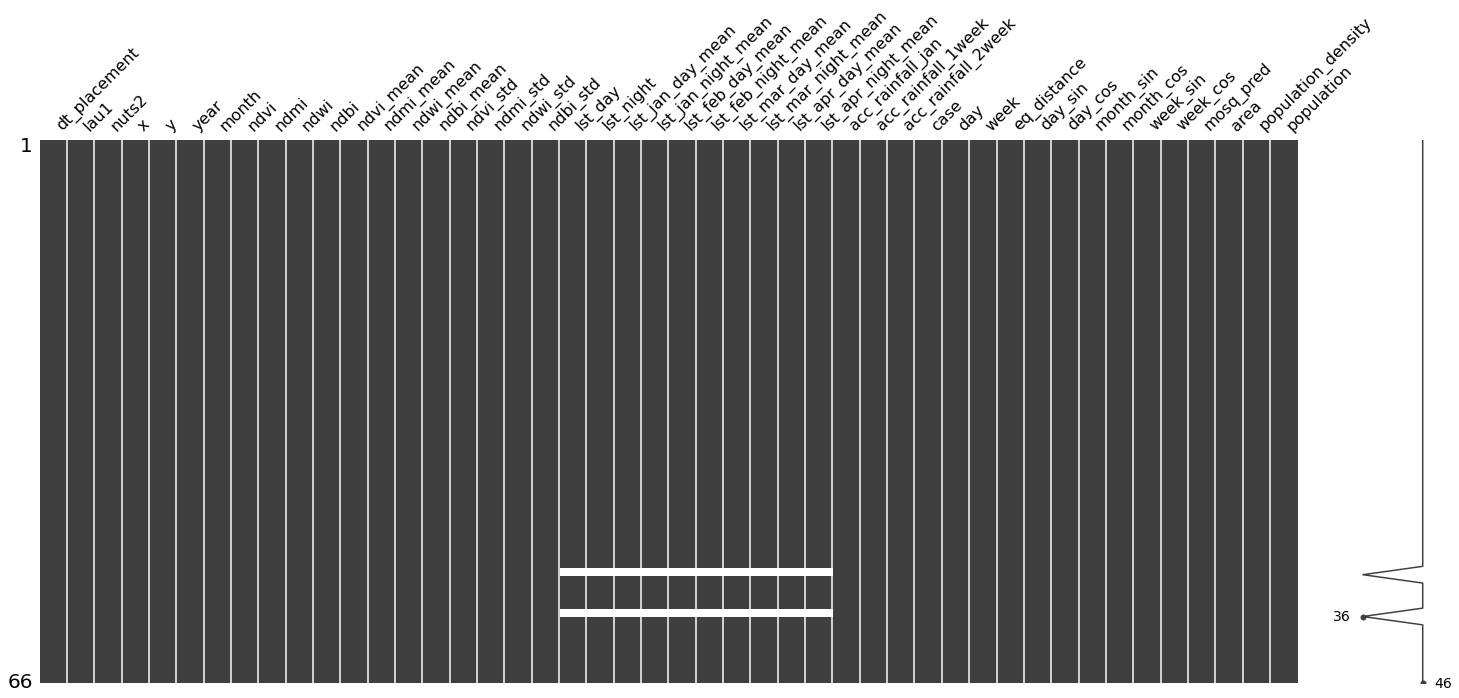

In [52]:
missingno.matrix(dataset)

In [53]:
missing = describe_dataframe(dataset)

In [54]:
dataset

,dt_placement,lau1,nuts2,x,y,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,lst_jan_day_mean,lst_jan_night_mean,lst_feb_day_mean,lst_feb_night_mean,lst_mar_day_mean,lst_mar_night_mean,lst_apr_day_mean,lst_apr_night_mean,acc_rainfall_jan,acc_rainfall_1week,acc_rainfall_2week,case,day,week,eq_distance,day_sin,day_cos,month_sin,month_cos,week_sin,week_cos,mosq_pred,area,population_density,population
0,2023-08-16,αγιας βαρβαρας,αττικης,23.65697,37.99220,2023,8,0.010814,0.055814,0.001571,-0.055814,0.048130,0.023736,-0.047578,-0.023736,0.042733,0.019531,0.049336,0.019531,15556.000000,15000.000000,14383.000000,14058.500000,14342.555556,13972.380952,14651.923077,14207.846154,14829.846154,14265.500000,348.910701,0.0,0.000000,0,16,33,44.75555,-0.101168,-0.994869,-0.866025,-0.5,-0.696551,-0.717507,180,2.4,10925.9,26759.0
1,2023-08-16,αγιας παρασκευης,αττικης,23.82642,38.00806,2023,8,0.191321,0.024308,-0.222122,-0.024308,0.194652,0.028120,-0.220625,-0.028120,0.022706,0.014833,0.016365,0.014833,15439.000000,14927.000000,14333.928571,14047.200000,14411.600000,13959.363636,14596.000000,14136.000000,14752.555556,14223.200000,425.951674,0.0,0.000000,0,16,33,44.85879,-0.101168,-0.994869,-0.866025,-0.5,-0.696551,-0.717507,64,7.9,7557.5,62157.0
2,2023-08-16,αγιου δημητριου,αττικης,23.73031,37.93357,2023,8,0.117532,-0.028843,-0.179234,0.028843,0.041143,-0.007720,-0.067075,0.007720,0.000000,0.000000,0.000000,0.000000,15489.000000,14991.000000,14390.461538,14124.550000,14357.363636,13996.130435,14688.400000,14187.062500,14885.647059,14302.500000,365.646401,0.0,0.000000,0,16,33,44.74465,-0.101168,-0.994869,-0.866025,-0.5,-0.696551,-0.717507,172,5.0,14402.8,71747.0
3,2023-08-16,αγιων αναργυρων καματερου,αττικης,23.71341,38.04721,2023,8,0.133692,-0.070526,-0.189098,0.070526,0.167988,-0.068353,-0.211268,0.068353,0.022130,0.026346,0.020000,0.026346,15576.000000,14994.000000,14369.750000,14037.578947,14313.300000,13963.473684,14693.000000,14156.333333,14841.250000,14223.666667,437.278102,0.0,0.000000,0,16,33,44.83209,-0.101168,-0.994869,-0.866025,-0.5,-0.696551,-0.717507,78,9.2,6833.8,61427.0
4,2023-08-16,αγκιστριου,αττικης,23.34009,37.69503,2023,8,0.292929,-0.052133,-0.238870,0.052133,0.305424,-0.037109,-0.253252,0.037109,0.025965,0.053238,0.012187,0.053238,15225.000000,14979.000000,14368.608696,14189.722222,14305.315789,14124.388889,14433.318182,14238.400000,14545.680000,14261.666667,485.616961,0.0,0.008986,0,16,33,44.33593,-0.101168,-0.994869,-0.866025,-0.5,-0.696551,-0.717507,57,13.4,85.2,1107.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
61,2023-08-16,φιλοθεης ψυχικου,αττικης,23.77628,38.01477,2023,8,0.270066,0.052220,-0.277910,-0.052220,0.241266,0.033742,-0.260575,-0.033742,0.028055,0.024144,0.020873,0.024144,15471.000000,14903.000000,14336.631579,14058.052632,14351.083333,13962.608696,14601.846154,14136.722222,14814.133333,14253.928571,437.278102,0.0,0.000000,0,16,33,44.83787,-0.101168,-0.994869,-0.866025,-0.5,-0.696551,-0.717507,45,6.1,4421.0,27400.0
62,2023-08-16,φυλης,αττικης,23.67294,38.10558,2023,8,0.309681,0.019178,-0.284842,-0.019178,0.244765,0.020092,-0.209366,-0.020092,0.038511,0.033112,0.043795,0.033112,15418.500000,14820.000000,14321.314273,13955.547386,14289.078047,13877.732260,14537.344780,14033.446337,14739.469093,14115.791035,410.047369,0.0,0.000000,0,16,33,44.86026,-0.101168,-0.994869,-0.866025,-0.5,-0.696551,-0.717507,46,109.1,421.2,48255.0
63,2023-08-16,χαλανδριου,αττικης,23.80941,38.02226,2023,8,0.216582,0.039957,-0.243138,-0.039957,0.223762,0.039369,-0.247848,-0.039369,0.047232,0.033458,0.032985,0.033458,15456.000000,14931.000000,14348.000000,14057.578947,14377.500000,13986.142857,14647.666667,14128.588235,14793.333333,14171.142857,425.951674,0.0,0.000000,0,16,33,44.86179,-0.101168,-0.994869,-0.866025,-0.5,-0.6

In [55]:
dataset = calculate_mosq_previous(dataset)

In [56]:
dataset = convert_temperature(dataset)

<AxesSubplot:>

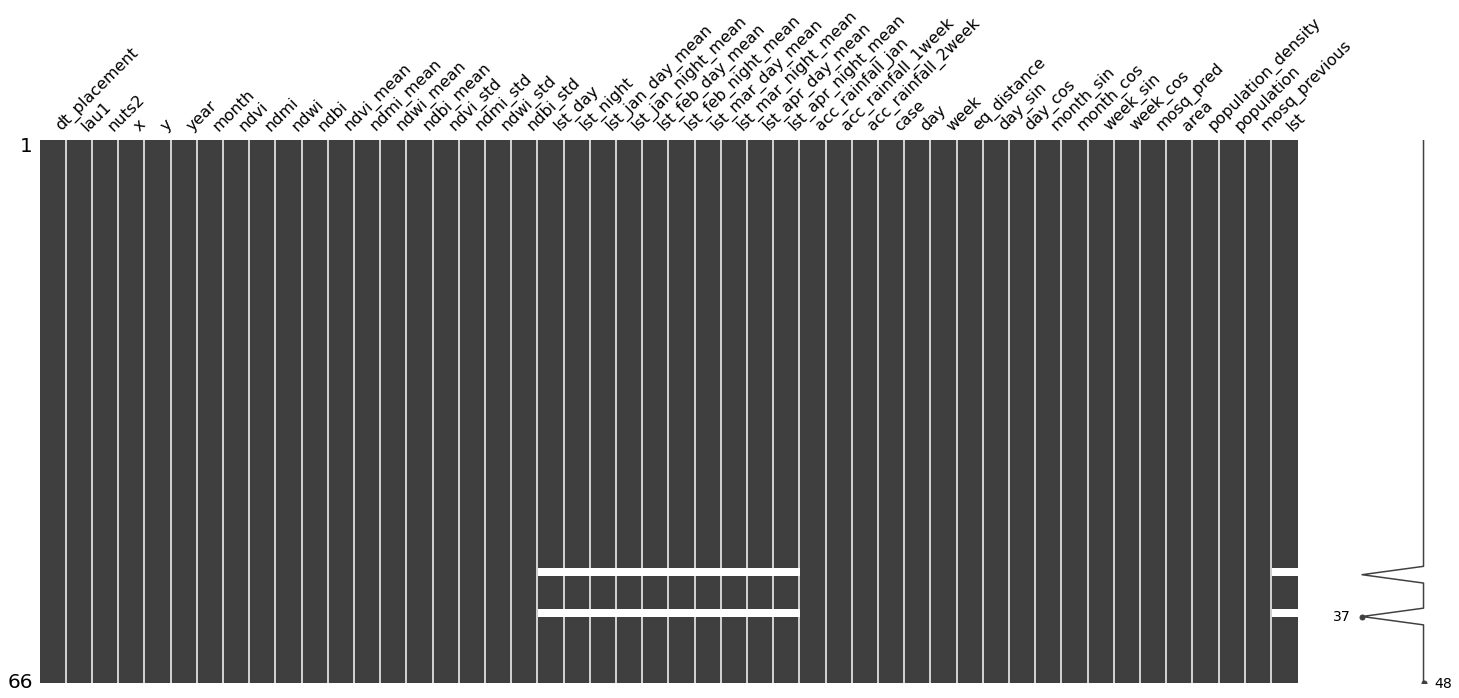

In [57]:
missingno.matrix(dataset)

In [58]:
dataset['case'].value_counts()

0    66
Name: case, dtype: int64

In [59]:
dataset = dataset.astype({'mosq_pred' : 'int', 'mosq_previous' : 'int'})

In [60]:
dataset['case'].value_counts()

0    66
Name: case, dtype: int64

In [61]:
cols = dataset.columns

In [62]:
cols

Index(['dt_placement', 'lau1', 'nuts2', 'x', 'y', 'year', 'month', 'ndvi',
       'ndmi', 'ndwi', 'ndbi', 'ndvi_mean', 'ndmi_mean', 'ndwi_mean',
       'ndbi_mean', 'ndvi_std', 'ndmi_std', 'ndwi_std', 'ndbi_std', 'lst_day',
       'lst_night', 'lst_jan_day_mean', 'lst_jan_night_mean',
       'lst_feb_day_mean', 'lst_feb_night_mean', 'lst_mar_day_mean',
       'lst_mar_night_mean', 'lst_apr_day_mean', 'lst_apr_night_mean',
       'acc_rainfall_jan', 'acc_rainfall_1week', 'acc_rainfall_2week', 'case',
       'day', 'week', 'eq_distance', 'day_sin', 'day_cos', 'month_sin',
       'month_cos', 'week_sin', 'week_cos', 'mosq_pred', 'area',
       'population_density', 'population', 'mosq_previous', 'lst'],
      dtype='object')

In [63]:
len(cols)

48

In [64]:
rearranged_columns = ['x', 'y', 'dt_placement', 'nuts2', 'lau1', 'day', 
                 'month', 'week', 'year', 'day_sin', 'day_cos', 'month_sin', 
                 'month_cos', 'week_sin', 'week_cos', 'area', 'population',
                 'population_density', 'eq_distance', 'ndvi', 'ndmi', 'ndwi', 'ndbi', 
                 'ndvi_mean', 'ndmi_mean', 'ndwi_mean', 'ndbi_mean', 
                 'ndvi_std', 'ndmi_std', 'ndwi_std', 'ndbi_std', 'lst',
                 'lst_day', 'lst_night','lst_jan_day_mean', 'lst_jan_night_mean', 
                 'lst_feb_day_mean','lst_feb_night_mean', 'lst_mar_day_mean', 
                 'lst_mar_night_mean', 'lst_apr_day_mean', 'lst_apr_night_mean',
                 'acc_rainfall_1week', 'acc_rainfall_2week', 'acc_rainfall_jan',
                 'mosq_pred', 'mosq_previous', 'case']

In [66]:
len(rearranged_columns)

48

In [67]:
dataset = dataset[rearranged_columns].copy()

In [68]:
dataset

,x,y,dt_placement,nuts2,lau1,day,month,week,year,day_sin,day_cos,month_sin,month_cos,week_sin,week_cos,area,population,population_density,eq_distance,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst,lst_day,lst_night,lst_jan_day_mean,lst_jan_night_mean,lst_feb_day_mean,lst_feb_night_mean,lst_mar_day_mean,lst_mar_night_mean,lst_apr_day_mean,lst_apr_night_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_jan,mosq_pred,mosq_previous,case
0,23.65697,37.99220,2023-08-16,αττικης,αγιας βαρβαρας,16,8,33,2023,-0.101168,-0.994869,-0.866025,-0.5,-0.696551,-0.717507,2.4,26759.0,10925.9,44.75555,0.010814,0.055814,0.001571,-0.055814,0.048130,0.023736,-0.047578,-0.023736,0.042733,0.019531,0.049336,0.019531,32.410000,37.970000,26.850000,14.510000,8.020000,13.701111,6.297619,19.888462,11.006923,23.446923,12.160000,0.0,0.000000,348.910701,180,0,0
1,23.82642,38.00806,2023-08-16,αττικης,αγιας παρασκευης,16,8,33,2023,-0.101168,-0.994869,-0.866025,-0.5,-0.696551,-0.717507,7.9,62157.0,7557.5,44.85879,0.191321,0.024308,-0.222122,-0.024308,0.194652,0.028120,-0.220625,-0.028120,0.022706,0.014833,0.016365,0.014833,30.510000,35.630000,25.390000,13.528571,7.794000,15.082000,6.037273,18.770000,9.570000,21.901111,11.314000,0.0,0.000000,425.951674,64,0,0
2,23.73031,37.93357,2023-08-16,αττικης,αγιου δημητριου,16,8,33,2023,-0.101168,-0.994869,-0.866025,-0.5,-0.696551,-0.717507,5.0,71747.0,14402.8,44.74465,0.117532,-0.028843,-0.179234,0.028843,0.041143,-0.007720,-0.067075,0.007720,0.000000,0.000000,0.000000,0.000000,31.650000,36.630000,26.670000,14.659231,9.341000,13.997273,6.772609,20.618000,10.591250,24.562941,12.900000,0.0,0.000000,365.646401,172,0,0
3,23.71341,38.04721,2023-08-16,αττικης,αγιων αναργυρων καματερου,16,8,33,2023,-0.101168,-0.994869,-0.866025,-0.5,-0.696551,-0.717507,9.2,61427.0,6833.8,44.83209,0.133692,-0.070526,-0.189098,0.070526,0.167988,-0.068353,-0.211268,0.068353,0.022130,0.026346,0.020000,0.026346,32.550000,38.370000,26.730000,14.245000,7.601579,13.116000,6.119474,20.710000,9.976667,23.675000,11.323333,0.0,0.000000,437.278102,78,0,0
4,23.34009,37.69503,2023-08-16,αττικης,αγκιστριου,16,8,33,2023,-0.101168,-0.994869,-0.866025,-0.5,-0.696551,-0.717507,13.4,1107.0,85.2,44.33593,0.292929,-0.052133,-0.238870,0.052133,0.305424,-0.037109,-0.253252,0.037109,0.025965,0.053238,0.012187,0.053238,28.890000,31.350000,26.430000,14.222174,10.644444,12.956316,9.337778,15.516364,11.618000,17.763600,12.083333,0.0,0.008986,485.616961,57,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
61,23.77628,38.01477,2023-08-16,αττικης,φιλοθεης ψυχικου,16,8,33,2023,-0.101168,-0.994869,-0.866025,-0.5,-0.696551,-0.717507,6.1,27400.0,4421.0,44.83787,0.270066,0.052220,-0.277910,-0.052220,0.241266,0.033742,-0.260575,-0.033742,0.028055,0.024144,0.020873,0.024144,30.590000,36.270000,24.910000,13.582632,8.011053,13.871667,6.102174,18.886923,9.584444,23.132667,11.928571,0.0,0.000000,437.278102,45,0,0
62,23.67294,38.10558,2023-08-16,αττικης,φυλης,16,8,33,2023,-0.101168,-0.994869,-0.866025,-0.5,-0.696551,-0.717507,109.1,48255.0,421.2,44.86026,0.309681,0.019178,-0.284842,-0.019178,0.244765,0.020092,-0.209366,-0.020092,0.038511,0.033112,0.043795,0.033112,29.235000,35.220000,23.250000,13.276285,5.960948,12.631561,4.404645,17.596896,7.518927,21.639382,9.165821,0.0,0.000000,410.047369,46,0,0
63,23.80941,38.02226,2023-08-16,αττικης,χαλανδριου,16,8,33,2023,-0.101168,-0.994869,-0.866025,-0.5,-0.696551,-0.717507,10.8,77118.0,6869.6,44.86179,0.216582,0.039957,-0.243138,-0.039957,0.223762,0.039369,-0.247848,-0.039369,0.047232,0.033458,0.032985,0.033458,30.720000,35.970000,25.470000,13.810000,8.001579,14.400000,6.572857,19.803333,9.421765,22.716667,10.272857,0.0,0.000000,425.951674,47,0,0
64,23.63084,38.00942,2023-08-16,αττικης,χαϊδαριου,16,8,33,2023,-0.101168,-0.994869,-0.866025,-0.5,-0

### Add geomorphological features ###

In [69]:
geomorphological = pd.read_csv(f'../../data/{NUTS2}/{NUTS0}_{NUTS2}_Geomorphological_filled.csv')
geomorphological.columns = geomorphological.columns.str.lower()

In [70]:
distances, indicies = calculate_nearest_topological(dataset, geomorphological)
print(f'Min distance: {min(distances)}')
print(f'Max distance: {max(distances)}')

Min distance: 0.0
Max distance: 6.802114029266602


In [71]:
df_geo = pd.DataFrame(columns=geomorphological.columns)

for index in indicies:
    df_geo = df_geo.append(geomorphological.iloc[[index]])

df_geo.drop(columns=['x', 'y'], inplace = True)
df_geo.reset_index(drop=True, inplace=True)

In [72]:
dataset = pd.concat([dataset, df_geo], axis=1, join = 'outer')
dataset.head()

,x,y,dt_placement,nuts2,lau1,day,month,week,year,day_sin,day_cos,month_sin,month_cos,week_sin,week_cos,area,population,population_density,eq_distance,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst,lst_day,lst_night,lst_jan_day_mean,lst_jan_night_mean,lst_feb_day_mean,lst_feb_night_mean,lst_mar_day_mean,lst_mar_night_mean,lst_apr_day_mean,lst_apr_night_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_jan,mosq_pred,mosq_previous,case,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m
0,23.65697,37.99220,2023-08-16,αττικης,αγιας βαρβαρας,16,8,33,2023,-0.101168,-0.994869,-0.866025,-0.5,-0.696551,-0.717507,2.4,26759.0,10925.9,44.75555,0.010814,0.055814,0.001571,-0.055814,0.048130,0.023736,-0.047578,-0.023736,0.042733,0.019531,0.049336,0.019531,32.41,37.97,26.85,14.510000,8.020000,13.701111,6.297619,19.888462,11.006923,23.446923,12.160000,0.0,0.000000,348.910701,180,0,0,4986.234414,2455.349701,5,136.450508,101.355755,167.697476,0.000000,1.730851
1,23.82642,38.00806,2023-08-16,αττικης,αγιας παρασκευης,16,8,33,2023,-0.101168,-0.994869,-0.866025,-0.5,-0.696551,-0.717507,7.9,62157.0,7557.5,44.85879,0.191321,0.024308,-0.222122,-0.024308,0.194652,0.028120,-0.220625,-0.028120,0.022706,0.014833,0.016365,0.014833,30.51,35.63,25.39,13.528571,7.794000,15.082000,6.037273,18.770000,9.570000,21.901111,11.314000,0.0,0.000000,425.951674,64,0,0,14419.406690,1186.404835,17,195.624294,247.122730,186.152654,0.000000,4.727984
2,23.73031,37.93357,2023-08-16,αττικης,αγιου δημητριου,16,8,33,2023,-0.101168,-0.994869,-0.866025,-0.5,-0.696551,-0.717507,5.0,71747.0,14402.8,44.74465,0.117532,-0.028843,-0.179234,0.028843,0.041143,-0.007720,-0.067075,0.007720,0.000000,0.000000,0.000000,0.000000,31.65,36.63,26.67,14.659231,9.341000,13.997273,6.772609,20.618000,10.591250,24.562941,12.900000,0.0,0.000000,365.646401,172,0,0,3030.589205,923.760750,6,197.484591,76.843700,185.824323,0.000000,10.672627
3,23.71341,38.04721,2023-08-16,αττικης,αγιων αναργυρων καματερου,16,8,33,2023,-0.101168,-0.994869,-0.866025,-0.5,-0.696551,-0.717507,9.2,61427.0,6833.8,44.83209,0.133692,-0.070526,-0.189098,0.070526,0.167988,-0.068353,-0.211268,0.068353,0.022130,0.026346,0.020000,0.026346,32.55,38.37,26.73,14.245000,7.601579,13.116000,6.119474,20.710000,9.976667,23.675000,11.323333,0.0,0.000000,437.278102,78,0,0,10104.114693,102.938851,2,185.470524,110.515124,178.698121,0.000000,247.581759
4,23.34009,37.69503,2023-08-16,αττικης,αγκιστριου,16,8,33,2023,-0.101168,-0.994869,-0.866025,-0.5,-0.696551,-0.717507,13.4,1107.0,85.2,44.33593,0.292929,-0.052133,-0.238870,0.052133,0.305424,-0.037109,-0.253252,0.037109,0.025965,0.053238,0.012187,0.053238,28.89,31.35,26.43,14.222174,10.644444,12.956316,9.337778,15.516364,11.618000,17.763600,12.083333,0.0,0.008986,485.616961,57,0,0,703.682089,16702.208116,8,264.649030,132.349467,189.350397,0.115955,1.705489


<AxesSubplot:>

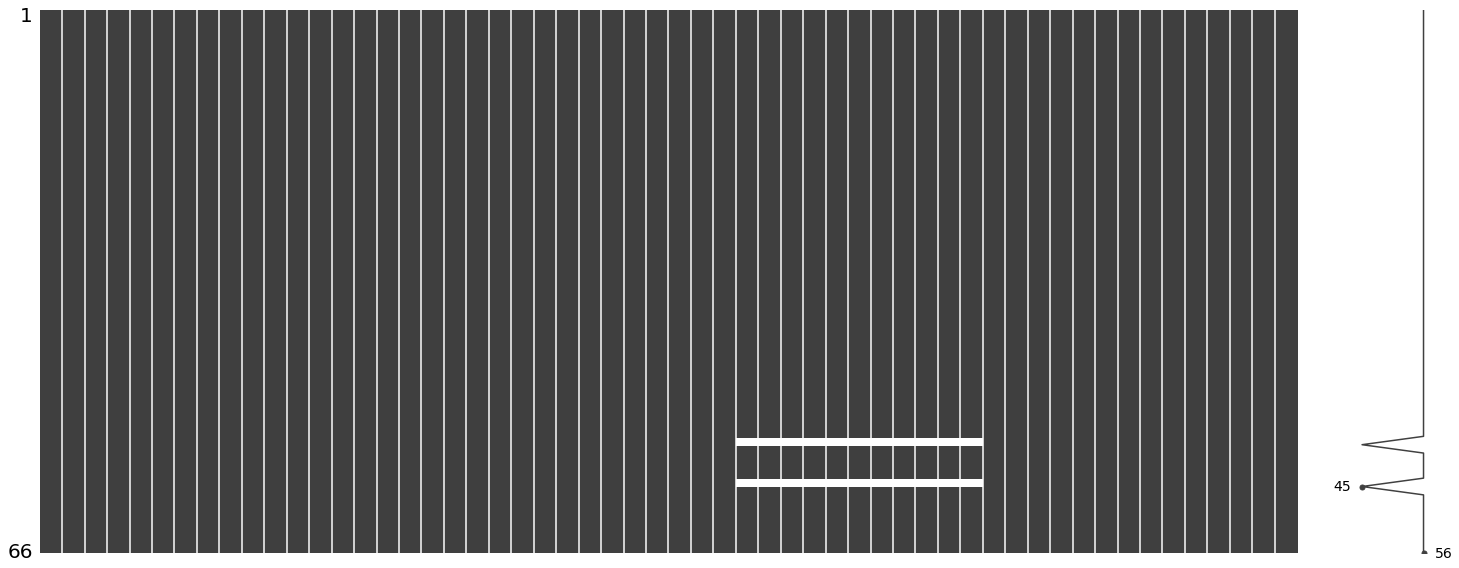

In [73]:
missingno.matrix(dataset)

In [74]:
cols = dataset.columns
cols

Index(['x', 'y', 'dt_placement', 'nuts2', 'lau1', 'day', 'month', 'week',
       'year', 'day_sin', 'day_cos', 'month_sin', 'month_cos', 'week_sin',
       'week_cos', 'area', 'population', 'population_density', 'eq_distance',
       'ndvi', 'ndmi', 'ndwi', 'ndbi', 'ndvi_mean', 'ndmi_mean', 'ndwi_mean',
       'ndbi_mean', 'ndvi_std', 'ndmi_std', 'ndwi_std', 'ndbi_std', 'lst',
       'lst_day', 'lst_night', 'lst_jan_day_mean', 'lst_jan_night_mean',
       'lst_feb_day_mean', 'lst_feb_night_mean', 'lst_mar_day_mean',
       'lst_mar_night_mean', 'lst_apr_day_mean', 'lst_apr_night_mean',
       'acc_rainfall_1week', 'acc_rainfall_2week', 'acc_rainfall_jan',
       'mosq_pred', 'mosq_previous', 'case', 'distance_to_coast',
       'distance_to_river', 'slope_mean_1km', 'aspect_mean_200m',
       'elevation_mean_1km', 'hillshade_mean_1km', 'fs_area_1km',
       'flow_accu_200m'],
      dtype='object')

In [75]:
len(cols)

56

In [76]:
rearranged_columns = ['x', 'y', 'dt_placement', 'nuts2', 'lau1', 'day', 'month',
       'week', 'year', 'day_sin', 'day_cos', 'month_sin', 'month_cos',
       'week_sin', 'week_cos', 'area', 'population', 'population_density',
       'eq_distance', 'ndvi', 'ndmi', 'ndwi', 'ndbi', 'ndvi_mean', 'ndmi_mean',
       'ndwi_mean', 'ndbi_mean', 'ndvi_std', 'ndmi_std', 'ndwi_std',
       'ndbi_std', 'lst', 'lst_day', 'lst_night', 'lst_jan_day_mean',
       'lst_jan_night_mean', 'lst_feb_day_mean', 'lst_feb_night_mean',
       'lst_mar_day_mean', 'lst_mar_night_mean', 'lst_apr_day_mean',
       'lst_apr_night_mean', 'acc_rainfall_1week', 'acc_rainfall_2week',
       'acc_rainfall_jan', 'distance_to_coast', 'distance_to_river', 'slope_mean_1km',
       'aspect_mean_200m', 'elevation_mean_1km', 'hillshade_mean_1km',
       'fs_area_1km', 'flow_accu_200m', 'mosq_pred', 'mosq_previous', 'case']

In [77]:
len(rearranged_columns)

56

In [78]:
dataset = dataset[rearranged_columns]

### Add Landcover features ###

In [79]:
landcover = pd.read_csv(f'../../data/{NUTS2}/{NUTS0}_{NUTS2}_Landcover_2001-2021_filled.csv')
landcover.columns = landcover.columns.str.lower()

In [80]:
lc_columns = landcover.columns.tolist()
lc_columns = [x.split('_')[0] for x in lc_columns]

lc_columns
lc_years = set()

for i in range(0, len(lc_columns)):
    try:
        lc_years.add(int(lc_columns[i]))
    except ValueError:
        pass

lc_years = list(lc_years)

In [81]:
dates_ = re.compile(r"[0-9]{4}_[0-9]{2}_[0-9]{2}_")

for year in lc_years:
    frame_name = f'landcover_{year}'
    location_columns = ['x', 'y']
    filtered_columns = [col for col in landcover if col.startswith(f'{year}')]
    columns_to_keep = location_columns + filtered_columns
    locals()[frame_name] = landcover[columns_to_keep].copy()
    locals()[frame_name].insert(2, 'year', int(year))
    locals()[frame_name] = locals()[frame_name].rename(columns=lambda x: re.sub(dates_,'',x))
    

In [82]:
data_years = dataset['year'].unique().tolist()

In [83]:
for year in data_years:
    frame_name = f'dataset_{year}'
    locals()[frame_name] = dataset.query(f"year == {year}").copy()
    locals()[frame_name].reset_index(drop=True, inplace = True)

In [84]:
for year in data_years:
    data_name = f'dataset_{year}'
    lc_name = f'landcover_{year}'
    merged_name = f'dataset_part_{year}'
    distances, indicies = calculate_nearest_topological(locals()[data_name], locals()[lc_name])
    print(f'Year: {year}\nMin distance: {min(distances)}\nMax distance: {max(distances)}')

    df_lulc = pd.DataFrame()

    for index in indicies:
        df_lulc = df_lulc.append(locals()[lc_name].iloc[[index]])

    df_lulc.drop(columns=['x', 'y', 'year'], inplace = True)
    df_lulc.reset_index(drop=True, inplace=True)

    locals()[merged_name] = pd.concat([locals()[data_name], df_lulc], axis=1, join = 'outer')

Year: 2023
Min distance: 0.0
Max distance: 6.802114029266602


In [85]:
dataset_final = pd.DataFrame()

for year in data_years:
    merged_name = f'dataset_part_{year}'
    dataset_final = pd.concat([dataset_final, locals()[merged_name]], ignore_index=True)

<AxesSubplot:>

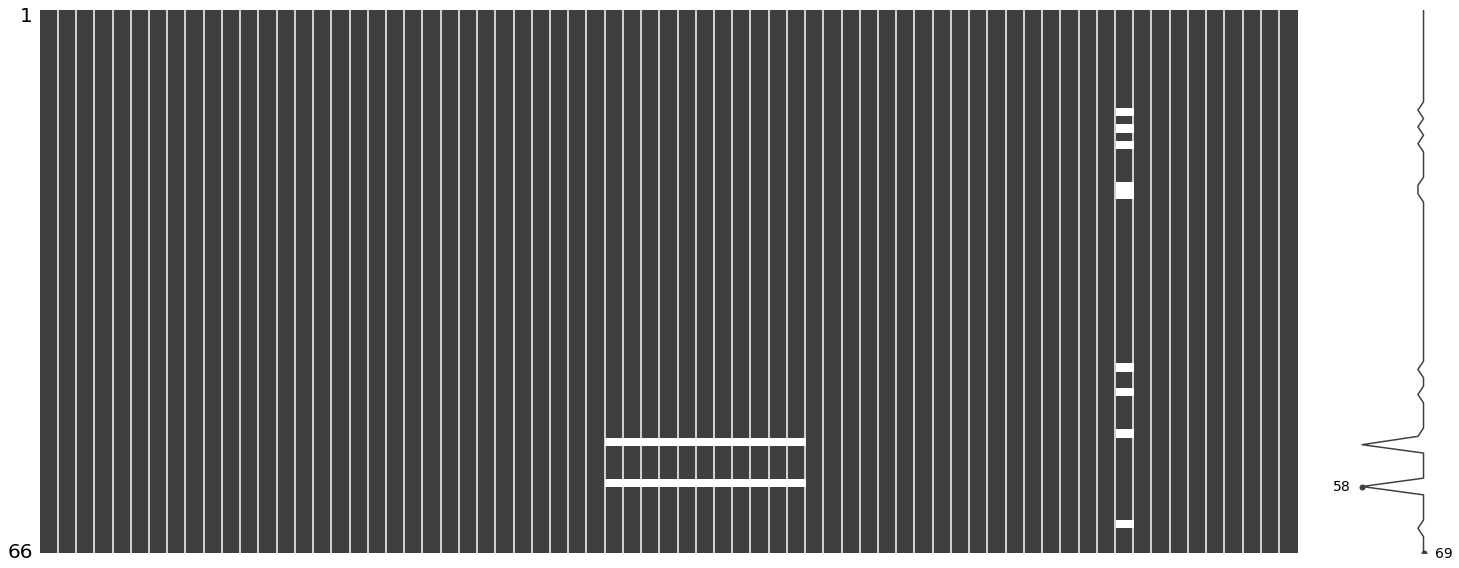

In [86]:
missingno.matrix(dataset_final)

In [87]:
cols = dataset_final.columns
cols

Index(['x', 'y', 'dt_placement', 'nuts2', 'lau1', 'day', 'month', 'week',
       'year', 'day_sin', 'day_cos', 'month_sin', 'month_cos', 'week_sin',
       'week_cos', 'area', 'population', 'population_density', 'eq_distance',
       'ndvi', 'ndmi', 'ndwi', 'ndbi', 'ndvi_mean', 'ndmi_mean', 'ndwi_mean',
       'ndbi_mean', 'ndvi_std', 'ndmi_std', 'ndwi_std', 'ndbi_std', 'lst',
       'lst_day', 'lst_night', 'lst_jan_day_mean', 'lst_jan_night_mean',
       'lst_feb_day_mean', 'lst_feb_night_mean', 'lst_mar_day_mean',
       'lst_mar_night_mean', 'lst_apr_day_mean', 'lst_apr_night_mean',
       'acc_rainfall_1week', 'acc_rainfall_2week', 'acc_rainfall_jan',
       'distance_to_coast', 'distance_to_river', 'slope_mean_1km',
       'aspect_mean_200m', 'elevation_mean_1km', 'hillshade_mean_1km',
       'fs_area_1km', 'flow_accu_200m', 'mosq_pred', 'mosq_previous', 'case',
       'lc_prop1', 'lc_prop1_assessment', 'lc_prop2', 'lc_prop2_assessment',
       'lc_prop3', 'lc_prop3_assessment', '

In [88]:
len(cols)

69

In [89]:
rearranged = ['x', 'y', 'dt_placement', 'nuts2', 'lau1', 'day', 'month',
       'week', 'year', 'day_sin', 'day_cos', 'month_sin', 'month_cos',
       'week_sin', 'week_cos', 'area', 'population', 'population_density',
       'eq_distance', 'ndvi', 'ndmi', 'ndwi', 'ndbi', 'ndvi_mean', 'ndmi_mean',
       'ndwi_mean', 'ndbi_mean', 'ndvi_std', 'ndmi_std', 'ndwi_std',
       'ndbi_std', 'lst', 'lst_day', 'lst_night', 'lst_jan_day_mean',
       'lst_jan_night_mean', 'lst_feb_day_mean', 'lst_feb_night_mean',
       'lst_mar_day_mean', 'lst_mar_night_mean', 'lst_apr_day_mean',
       'lst_apr_night_mean', 'acc_rainfall_1week', 'acc_rainfall_2week',
       'acc_rainfall_jan', 'distance_to_coast', 'distance_to_river', 
       'slope_mean_1km', 'aspect_mean_200m', 'elevation_mean_1km', 
       'hillshade_mean_1km', 'fs_area_1km', 'flow_accu_200m', 
       'lc_prop1', 'lc_prop1_assessment', 'lc_prop2', 'lc_prop2_assessment', 
       'lc_prop3', 'lc_prop3_assessment', 'lc_type1', 'lc_type2', 'lc_type3', 
       'lc_type4', 'lc_type5', 'lw', 'qc', 'mosq_pred', 'mosq_previous', 'case']

In [90]:
len(rearranged)

69

In [91]:
dataset_final = dataset_final[rearranged]

In [92]:
dataset_final.to_csv(f"../../data/{NUTS2}/{NUTS0}_{NUTS2}_WNV_Dataset_{YEAR}-{MONTH}-{PERIOD}.csv", encoding = enc, index = False)